In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# This is a template for assessing models using simulation, use this template to solve problem 1 and 2

## Problem 1: IS 296 Commuter Students Proportion representative of UMBC students? ##

In [15]:
#Step1: gather data
sample_size = 21
model_proportions = make_array(0.63, 0.37)
obs_value = 10
obs_value

10

In [16]:
sample_proportions(sample_size, model_proportions)

array([ 0.57142857,  0.42857143])

In [17]:
#Step2: run simulation
sim_values = make_array()
for i in np.arange(1000):
    new_value = sample_proportions(sample_size, model_proportions).item(0)* sample_size
    sim_values = np.append(sim_values, new_value)
sim_values[0:10]

array([ 15.,  17.,  13.,  16.,  14.,   7.,  13.,  14.,  11.,  15.])

P-value= 0.053


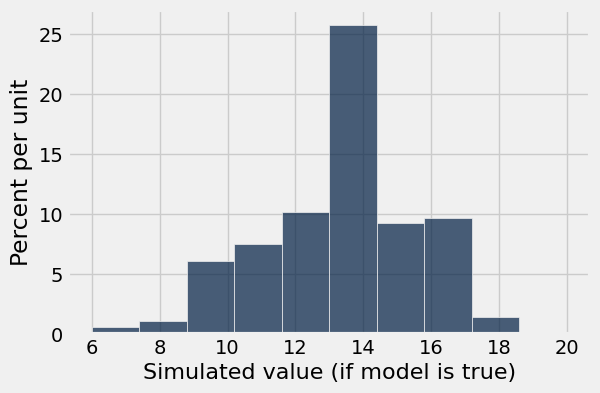

In [18]:
#Step 3: analyze results
Table().with_column('Simulated value (if model is true)', sim_values).hist() #  update
p_value = np.mean(sim_values < obs_value) # update
print('P-value=',str(p_value))

**Explanation**

This histogram represents the distribution of simulated values of the number of commuters there would be in a 21-person class, given that 63% of students at UMBC are commuters. Looking at the histogram, we see that the greatest value is 14, which is 66% of 21. Our observed value of 10 commuters is a fairly rare occurance in respect to the P-value of 0.053, which means about 5.3% of the simulated samples resulted in 10 or fewer commuters.

## Problem 2: NCHA data analysis (stress profile)

In [29]:
# utility function to calcualte tvd
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

In [30]:
#Step 1: Gather data

# UMBC student sample size
sample_size = 249
#Under the model (i.e. national sample), this is stress profile (i.e. distribution of stress category)
model = make_array(0.17, 0.215, 0.505, 0.263)
#This is UMBC student's stress profile
obs = make_array(0.31, 0.169, 0.469, 0.331)
obs_tvd = tvd(model, obs) # calculated observed tvd between observed distribution and model distribution
obs_tvd

0.14500000000000002

In [58]:
# Step2: Run simulation
sim_tvds = make_array()
num_simulations = 1000
for i in np.arange(num_simulations):
    new_tvd = tvd(sample_proportions(sample_size, model), model)
    sim_tvds = np.append(sim_tvds, new_tvd)
sim_tvds[0:10]

array([ 0.10348795,  0.09123896,  0.10113855,  0.11152008,  0.10246386,
        0.09041566,  0.11366867,  0.10965261,  0.10431124,  0.13242369])

P-value= 0.049


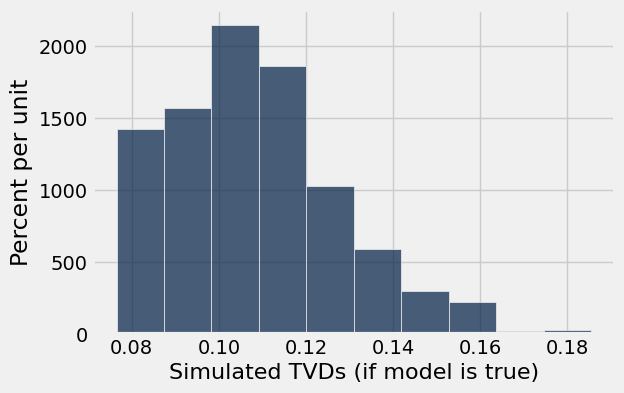

In [59]:
#Step 3: Analyze results
Table().with_column('Simulated TVDs (if model is true)', sim_tvds).hist() # update
p_value = np.mean(sim_tvds>obs_tvd) # update
print('P-value=',str(p_value))

**Explanation**

This histogram shows the distribution of TVDs between the national stress levels of college students and 1000 simulated stress levels. The histogram shows that for all simulations, the TVD is usually between 0.10 and 0.12.
UMBC's observed TVD is 0.145, which lies in the second half of the histogram. This means that UMBC's stress levels are quite high compared to the national level and the simulated levels The P-value = 0.049 means 4.9% of simulated trials had TVD of 0.145 or greater.

In [52]:
tbl_umbc = Table().with_columns(
    'Gender', make_array('Cis Men','Cis Women','Trans/Gender Non-conforming','Total'),
    'No stress', make_array(5.9, 2.2, 0, 3.1),
    'Low', make_array(27.1, 11.7, 11.1, 16.9),
    'Moderate', make_array(45.9, 48.2, 51.9, 46.9),
    'High', make_array(21.2, 38, 37, 33.1)
)
tbl_umbc

Gender,No stress,Low,Moderate,High
Cis Men,5.9,27.1,45.9,21.2
Cis Women,2.2,11.7,48.2,38
Trans/Gender Non-conforming,0,11.1,51.9,37
Total,3.1,16.9,46.9,33.1


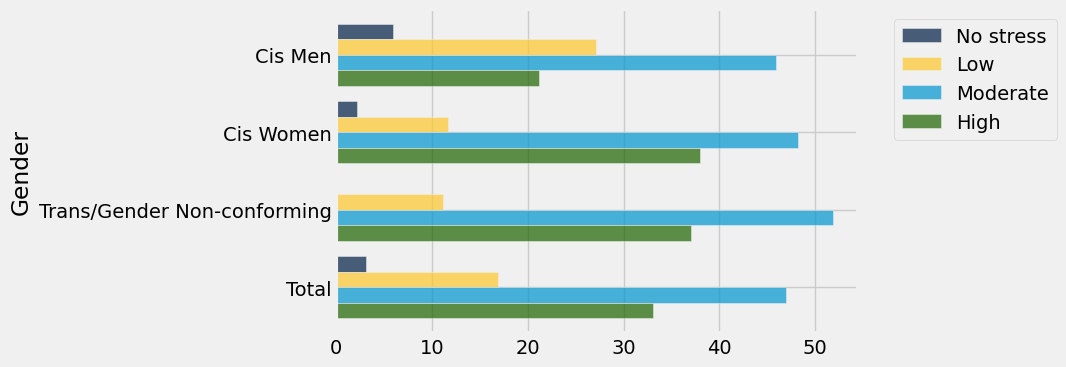

In [53]:
tbl_umbc.barh('Gender')

In [54]:
tbl_national = Table().with_columns(
    'Gender', make_array('Cis Men','Cis Women','Trans/Gender Non-conforming','Total'),
    'No stress', make_array(3.5, 1, 0.8, 1.7),
    'Low', make_array(32.7, 17.9, 12.8, 21.5),
    'Moderate', make_array(46.1, 52.5, 49.5, 50.5),
    'High', make_array(17.7, 28.5, 36.9, 26.3)
)
tbl_national

Gender,No stress,Low,Moderate,High
Cis Men,3.5,32.7,46.1,17.7
Cis Women,1,17.9,52.5,28.5
Trans/Gender Non-conforming,0.8,12.8,49.5,36.9
Total,1.7,21.5,50.5,26.3


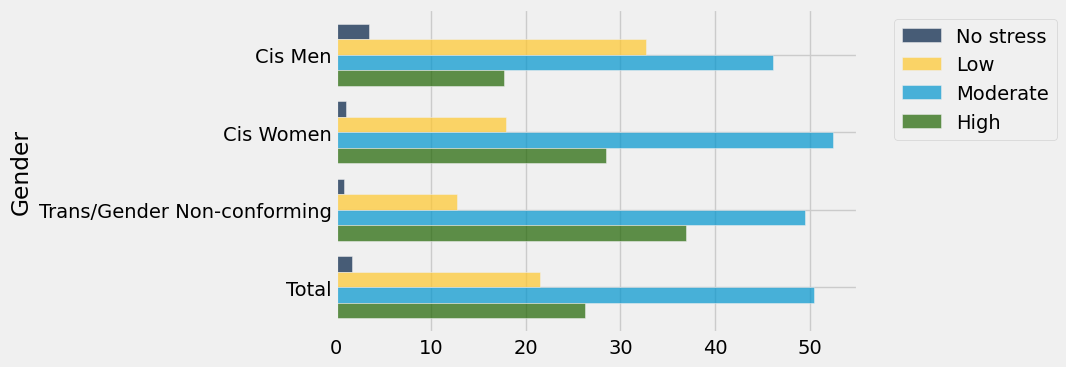

In [55]:
tbl_national.barh('Gender')